In [6]:
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm

[[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
    1.00000000e-01 -3.01033653e+03]
  [ 0.00000000e+00  2.40000000e+01  0.00000000e+00  0.00000000e+00
    1.00000000e-01 -3.01033653e+03]
  [ 0.00000000e+00  4.80000000e+01  0.00000000e+00  0.00000000e+00
    1.00000000e-01 -3.01033653e+03]
  [ 0.00000000e+00  7.20000000e+01  0.00000000e+00  0.00000000e+00
    1.00000000e-01 -3.01033653e+03]
  [ 0.00000000e+00  9.60000000e+01  0.00000000e+00  0.00000000e+00
    1.00000000e-01 -3.01033653e+03]
  [ 0.00000000e+00  1.20000000e+02  0.00000000e+00  0.00000000e+00
    1.00000000e-01 -3.01033653e+03]
  [ 0.00000000e+00  1.44000000e+02  0.00000000e+00  0.00000000e+00
    1.00000000e-01 -3.01033653e+03]
  [ 0.00000000e+00  1.68000000e+02  0.00000000e+00  0.00000000e+00
    1.00000000e-01 -3.01033653e+03]
  [ 0.00000000e+00  1.92000000e+02  0.00000000e+00  0.00000000e+00
    1.00000000e-01 -3.01033653e+03]
  [ 0.00000000e+00  2.16000000e+02  0.00000000e+00  0.00000000e+00
    1.

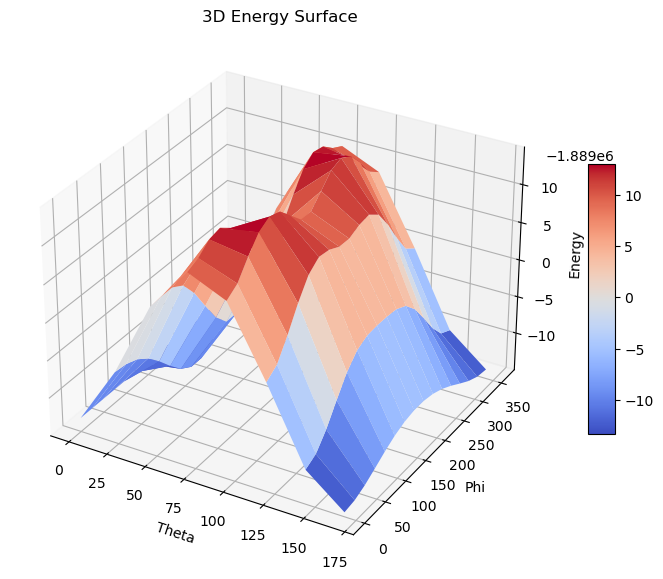

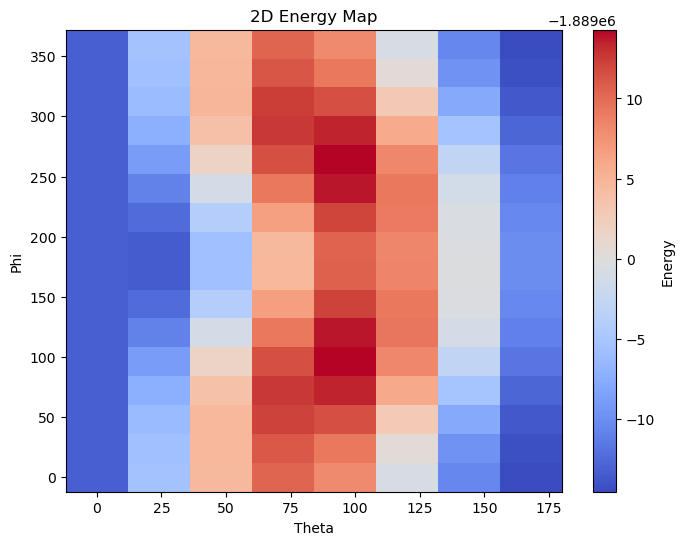

In [10]:
fs = np.loadtxt("para_field_scan_qeddft_wb97x-d.txt")

# in this case, there are 8 theta vals and 16 phi vals
fs_rs = fs.reshape((8,16,6))
print(fs_rs)

# au_to_kcal_per_mol
au_to_kc = 627.509

# Extract coordinates
# x = theta values (first column), y = phi values (second column)
x = fs_rs[:, 0, 0]  
y = fs_rs[0, :, 1]  
Z = fs_rs[:, :, 5] * au_to_kc # Energy values

# Create coordinate matrices 
# 'ij' indexing ensures X and Y match the (8, 16) shape of Z
X, Y = np.meshgrid(x, y, indexing='ij')

# --- Option 1: 3D Surface Plot ---
fig1, ax1 = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(10, 7))
surf = ax1.plot_surface(X, Y, Z, cmap=cm.coolwarm, edgecolor='none')

ax1.set_xlabel('Theta')
ax1.set_ylabel('Phi')
ax1.set_zlabel('Energy')
fig1.colorbar(surf, shrink=0.5, aspect=10)
plt.title("3D Energy Surface")

# --- Option 2: 2D Color Map (Heatmap) ---
fig2, ax2 = plt.subplots(figsize=(8, 6))
mesh = ax2.pcolormesh(X, Y, Z, cmap=cm.coolwarm, shading='auto')

ax2.set_xlabel('Theta')
ax2.set_ylabel('Phi')
fig2.colorbar(mesh, label='Energy')
plt.title("2D Energy Map")

plt.show()

ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (16, 8) and arg 2 with shape (8, 16).

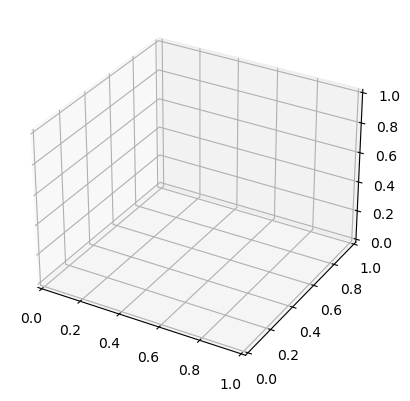

In [8]:
# 1. Prepare data
x = fs_rs[:,0,0]
y = fs_rs[0,:,0]
Z = fs_rs[:,:,5]
#y = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x, y)  # Create coordinate matrices
#Z = np.sin(np.sqrt(X**2 + Y**2)) # Example function

# 2. Create the plot
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
surf = ax.plot_surface(X, Y, Z, cmap=cm.coolwarm)